In [4]:
import json
import torch
from tqdm import tqdm
import seaborn as sns
from sklearn.manifold import TSNE
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from ssl_neuron.utils import plot_neuron, plot_tsne
from ssl_neuron.datasets import GraphDataset

import matplotlib.pyplot as plt

In [5]:
config = json.load(open('../configs/config.json'))
dset = GraphDataset(config, mode='all')

100%|██████████| 430/430 [00:03<00:00, 117.62it/s]


In [6]:
# load features from csv file
df = pd.read_csv('/home/chuyu/L-Measure/features.csv')

In [7]:
X = df.select_dtypes(include=[np.number]).copy()

In [8]:
scaler = StandardScaler()
latents = scaler.fit_transform(X)

In [9]:
colors = [list(sns.color_palette("mako", n_colors=10)[3])] + [list(sns.color_palette("mako", n_colors=10)[-2])]

In [10]:
z = TSNE(n_components=2, perplexity=30).fit_transform(latents)

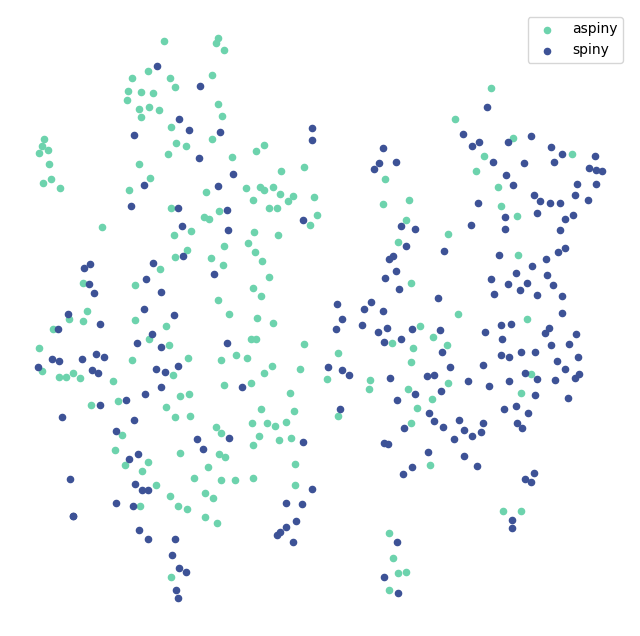

In [11]:
plot_tsne(z, np.concatenate([np.zeros(200, dtype=int), np.ones(230, dtype=int)]), targets=['aspiny', 'spiny'], colors=[colors[1], colors[0]])

In [17]:
# run k-means to cluster the latents into 20 clusters
from sklearn.cluster import KMeans
n_clusters = 5
kmeans = KMeans(n_clusters=n_clusters, random_state=0)
kmeans.fit(z)

,n_clusters,5
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,0
,copy_x,True
,algorithm,'lloyd'


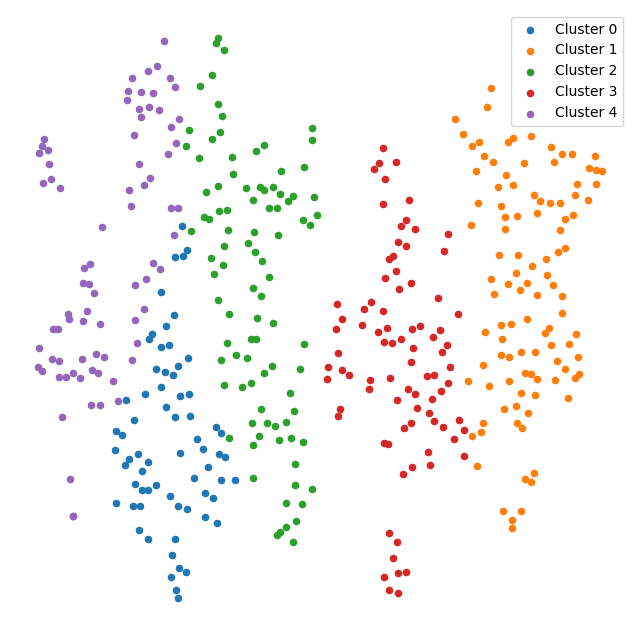

In [18]:
# plot tsne with cluster colors
plot_tsne(z, kmeans.labels_, targets=[f'Cluster {i}' for i in range(n_clusters)], colors=sns.color_palette("tab10", n_colors=n_clusters))

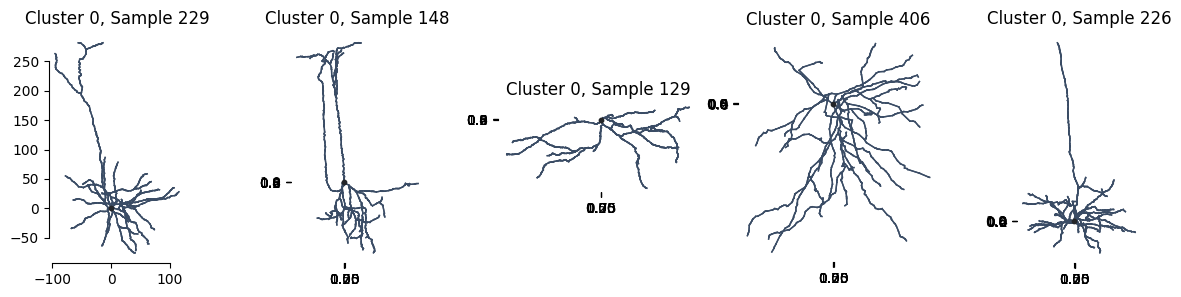

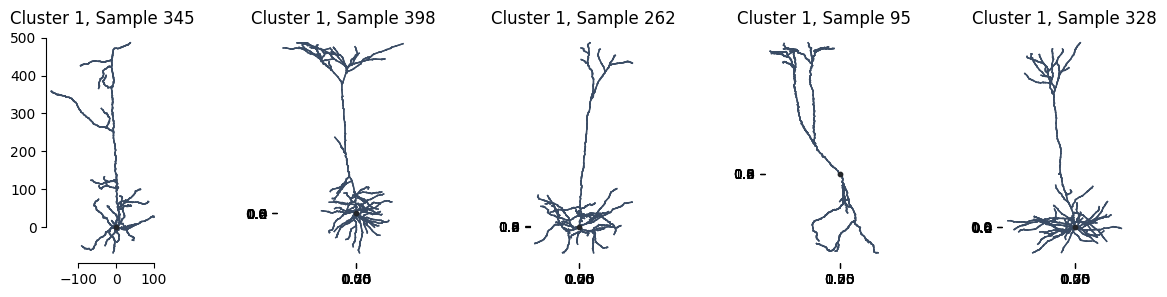

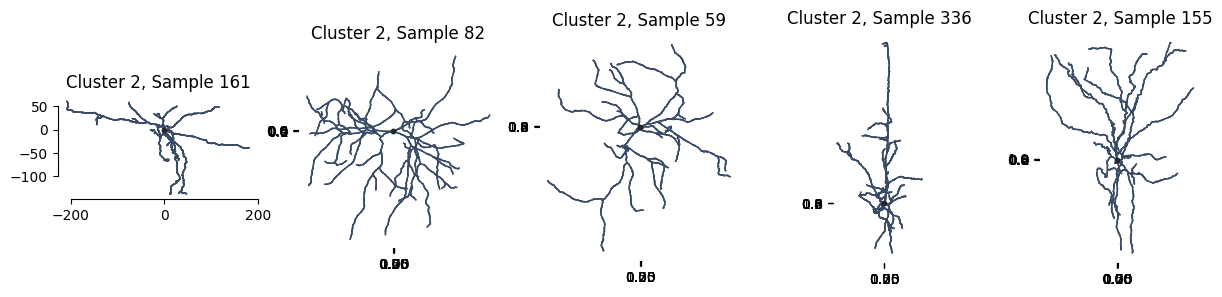

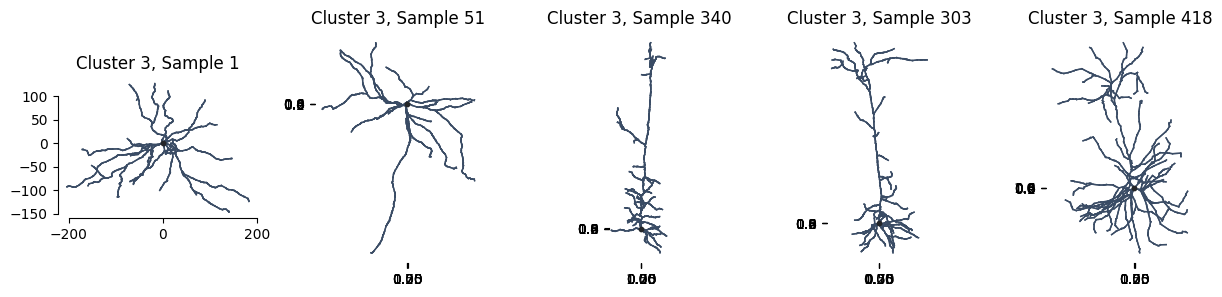

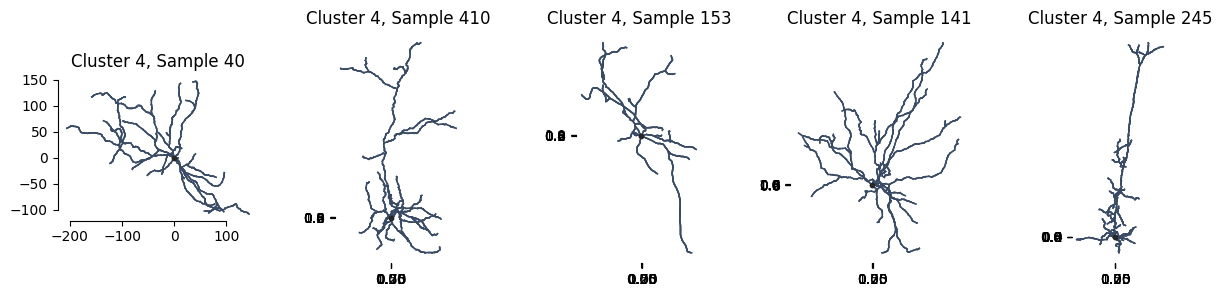

In [19]:
# plot 5 examples for each cluster
for cluster_id in range(n_clusters):
    cluster_indices = np.where(kmeans.labels_ == cluster_id)[0]
    selected_indices = np.random.choice(cluster_indices, size=5, replace=False)
    
    fig, axes = plt.subplots(1, 5, figsize=(15, 3))
    for ax, idx in zip(axes, selected_indices):
        feat, neigh = dset.__getsingleitem__(idx)
        plot_neuron(neigh, feat, ax=ax)
        ax.set_title(f'Cluster {cluster_id}, Sample {idx}')
    plt.show()